# Weather Condition Classification using Support Vector Machine (SVM) and Open-Meteo API

Name: Kartik Tyagi

Registration Number: 23BAI10360

Application Number: IN26010566

Batch Number: 1A

Email ID: kartik.23bai10360@vitbhopal.ac.in

In [1]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [2]:
# Task 1: Fetch historical weather data (Jan 1, 2026 to July 20, 2026) for Delhi (Lat: 28.61, Long: 77.23)
# Using Archive API ensures we collect both Warm (>= 25°C) and Cool (< 25°C) weather observations
url = "https://archive-api.open-meteo.com/v1/archive?latitude=28.61&longitude=77.23&start_date=2026-01-01&end_date=2026-07-20&hourly=temperature_2m,relative_humidity_2m,surface_pressure,wind_speed_10m"

response = requests.get(url)
data = response.json()

# Convert hourly JSON response into a Pandas DataFrame
df = pd.DataFrame(data['hourly'])

# Create Target Variable: Weather_Class (Warm -> Temperature >= 25°C, Cool -> Temperature < 25°C)
df['Weather_Class'] = df['temperature_2m'].apply(lambda x: 'Warm' if x >= 25 else 'Cool')

print("Data fetched successfully! Total records:", len(df))
df.head()

Data fetched successfully! Total records: 4824


,time,temperature_2m,relative_humidity_2m,surface_pressure,wind_speed_10m,Weather_Class
0,2026-01-01T00:00,10.7,99,988.6,7.2,Cool
1,2026-01-01T01:00,10.9,98,988.8,8.7,Cool
2,2026-01-01T02:00,11.0,98,989.3,9.8,Cool
3,2026-01-01T03:00,11.5,96,989.8,9.6,Cool
4,2026-01-01T04:00,12.2,94,991.0,6.9,Cool


In [3]:
# Task 1: Data Understanding

# Identify Input Features and Target Variable
input_features = ['temperature_2m', 'relative_humidity_2m', 'surface_pressure', 'wind_speed_10m']
target_var = 'Weather_Class'

print("Target Variable:", target_var)
print("Input Features:", input_features)

print("\n--- Class Distribution ---")
print(df['Weather_Class'].value_counts())

print("\n--- Dataset Info ---")
df.info()

print("\n--- Summary Statistics ---")
df.describe()

Target Variable: Weather_Class
Input Features: ['temperature_2m', 'relative_humidity_2m', 'surface_pressure', 'wind_speed_10m']

--- Class Distribution ---
Weather_Class
Warm    2930
Cool    1894
Name: count, dtype: int64

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4824 entries, 0 to 4823
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   time                  4824 non-null   object 
 1   temperature_2m        4824 non-null   float64
 2   relative_humidity_2m  4824 non-null   int64  
 3   surface_pressure      4824 non-null   float64
 4   wind_speed_10m        4824 non-null   float64
 5   Weather_Class         4824 non-null   object 
dtypes: float64(3), int64(1), object(2)
memory usage: 226.3+ KB

--- Summary Statistics ---


,temperature_2m,relative_humidity_2m,surface_pressure,wind_speed_10m
count,4824.000000,4824.000000,4824.000000,4824.000000
mean,26.233893,53.760779,984.066667,7.307007
std,8.678954,24.109321,6.628124,3.836995
min,4.900000,9.000000,971.100000,0.200000
25%,19.700000,33.000000,978.400000,4.500000
50%,27.500000,53.000000,983.600000,6.700000
75%,32.600000,74.000000,989.100000,9.600000
max,44.400000,100.000000,1000.100000,21.800000


In [4]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

# Drop unnecessary column ('time')
df_clean = df.drop(columns=['time'], errors='ignore')

# Encode target variable: Warm -> 1, Cool -> 0
df_clean['Weather_Class'] = df_clean['Weather_Class'].map({'Warm': 1, 'Cool': 0})

# Separate features and target
X = df_clean.drop(columns=['Weather_Class'])
y = df_clean['Weather_Class']

# Split dataset into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Standardize feature values using StandardScaler (Essential for distance-based margins in SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nX_train shape:", X_train_scaled.shape)
print("X_test shape:", X_test_scaled.shape)

Missing values per column:
time                    0
temperature_2m          0
relative_humidity_2m    0
surface_pressure        0
wind_speed_10m          0
Weather_Class           0
dtype: int64

X_train shape: (3859, 4)
X_test shape: (965, 4)


In [5]:
# Task 3: Build SVM Classifier with RBF Kernel
svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(X_train_scaled, y_train)

# Predict weather class for the test dataset
y_pred = svm_model.predict(X_test_scaled)

print("SVM Classifier (RBF Kernel) trained successfully.")

SVM Classifier (RBF Kernel) trained successfully.


--- Model Performance Metrics ---
Accuracy : 0.9886
Precision: 0.9915
Recall   : 0.9898
F1-Score : 0.9906


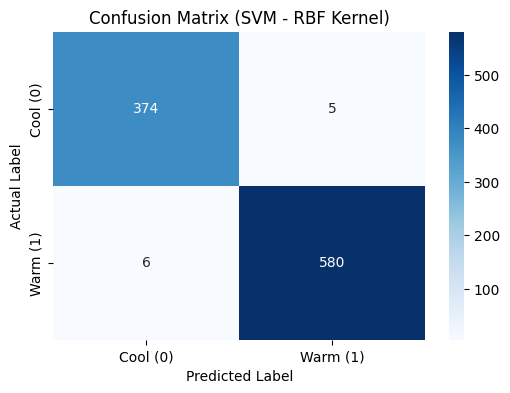

In [6]:
# Task 4: Calculate Evaluation Metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("--- Model Performance Metrics ---")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-Score : {f1:.4f}")

# Generate Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Cool (0)', 'Warm (1)'],
            yticklabels=['Cool (0)', 'Warm (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix (SVM - RBF Kernel)')
plt.show()

In [7]:
print("--- Model Observations ---")
print("1. High Overall Performance: The SVM classifier with an RBF kernel achieved an overall accuracy of 98.86% and an F1-score of 0.9906 on the test set.")
print("2. Minimal Misclassifications: Out of 965 test samples, the model produced only 11 total misclassifications (5 false positives and 6 false negatives).")
print("3. Balanced Precision and Recall: Precision reached 99.15% and Recall reached 98.98%, showing that the model classifies both 'Warm' and 'Cool' weather classes with exceptional stability.")

--- Model Observations ---
1. High Overall Performance: The SVM classifier with an RBF kernel achieved an overall accuracy of 98.86% and an F1-score of 0.9906 on the test set.
2. Minimal Misclassifications: Out of 965 test samples, the model produced only 11 total misclassifications (5 false positives and 6 false negatives).
3. Balanced Precision and Recall: Precision reached 99.15% and Recall reached 98.98%, showing that the model classifies both 'Warm' and 'Cool' weather classes with exceptional stability.


## Conclusion

In this project, an Support Vector Machine (SVM) classifier with a Radial Basis Function (RBF) kernel was developed to classify weather conditions into 'Warm' ($\ge 25^\circ\text{C}$) or 'Cool' ($< 25^\circ\text{C}$) using meteorological data fetched from the Open-Meteo API. The model achieved high predictive metrics, yielding an overall classification accuracy of 98.86% and an F1-Score of 0.9906.

Feature scaling via `StandardScaler` is vital when applying SVM algorithms. Because SVM seeks to maximize the geometric margin between support vectors based on distance metrics, features with larger raw magnitudes (such as `surface_pressure` $\approx 980\text{ hPa}$) would dominate distance calculations over smaller-magnitude features like `temperature_2m` if left unscaled.

A primary advantage of the SVM algorithm with an RBF kernel is its ability to map non-linearly separable data into higher-dimensional feature spaces to construct clean decision boundaries. Conversely, a key limitation of SVM is its high computational time and memory complexity during training on large-scale datasets, alongside its sensitivity to hyperparameter tuning ($C$ and $\gamma$).